Multicollinearity is a statistical phenomenon where two or more predictor variables in a regression model are highly correlated with each other. When multicollinearity exists, it becomes difficult to distinguish the individual effects of the independent variables on the dependent variable.

# Types of Multicollinearity

1. **Perfect Multicollinearity**: When one predictor variable is a perfect linear combination of another.

    Example: If X3 = 2 × X1 + 5 × X2, then X3 is perfectly collinear with X1 and X2.

2. **High (Imperfect) Multicollinearity**: When predictor variables are strongly correlated but not perfectly.

    Example: X1 (Age) and X2 (Years of Experience) will be highly correlated in many datasets.

# Why is Multicollinearity a Problem?

- **Unstable Coefficients**: The regression coefficients become unreliable and can change significantly with small changes in data.

- **Hard to Interpret**: It becomes difficult to determine which variable has a stronger impact on the target.

- **Increases Variance**: Multicollinearity inflates the standard errors, making coefficients statistically insignificant even if they are practically significant.

- **Computational Issues**: In extreme cases, it can cause singular matrix errors, making the regression model impossible to compute.



# Example of Multicollinearity
Consider a dataset predicting house prices based on:
- Size (sqft)
- Number of Rooms
- Number of Bathrooms
- Total Area (Size + Garage + Garden)

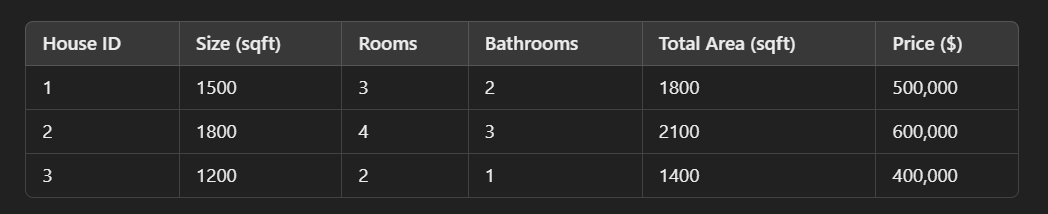

Here, "Size" and "Total Area" are highly correlated because Total Area already includes Size.

# How to Detect Multicollinearity?

## Correlation Matrix

- Compute the correlation between variables using Pearson correlation.
- If two independent variables have a `correlation > 0.8`, multicollinearity might be an issue.

In [1]:
import pandas as pd

# Sample dataset
data = {'Size': [1500, 1800, 1200],
        'Rooms': [3, 4, 2],
        'Bathrooms': [2, 3, 1],
        'Total_Area': [1800, 2100, 1400]}

df = pd.DataFrame(data)

# Compute correlation matrix
df.corr()

,Size,Rooms,Bathrooms,Total_Area
Size,1.000000,1.000000,1.000000,0.996616
Rooms,1.000000,1.000000,1.000000,0.996616
Bathrooms,1.000000,1.000000,1.000000,0.996616
Total_Area,0.996616,0.996616,0.996616,1.000000


## Variance Inflation Factor (VIF)

- A VIF > 5 indicates moderate multicollinearity.
- A VIF > 10 is severe multicollinearity.
- VIF of 1 means no correlation with other variables

In [2]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np

# Add a constant column for intercept
df['Intercept'] = 1  

# Compute VIF
X = df[['Size', 'Rooms', 'Bathrooms', 'Total_Area', 'Intercept']]
vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)


     Variable    VIF
0        Size    inf
1       Rooms    inf
2   Bathrooms    inf
3  Total_Area  148.0
4   Intercept    0.0


e:\notebook\notebook_env\lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
e:\notebook\notebook_env\lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


# Where Do We Use or Check for Multicollinearity?
Multicollinearity is mainly a concern in regression-based models where we analyze the impact of independent variables on a dependent variable. Below are some key scenarios where checking for multicollinearity is crucial:

## During Exploratory Data Analysis (EDA)
Before building any regression models, it's good practice to check for multicollinearity as part of your initial data exploration:

- When examining correlation matrices of your features
- When visualizing relationships between variables
- When you have domain knowledge suggesting variables might be related

## When Building Linear Models
Multicollinearity is especially important to check when using:

- Multiple Linear Regression
- Logistic Regression
- Generalized Linear Models (GLMs)
- Linear Discriminant Analysis (LDA)

These models are particularly sensitive to multicollinearity because they rely on calculating precise coefficient estimates.

## After Feature Engineering
Multicollinearity often emerges when:

- Creating derived features (e.g., BMI from height and weight)
- Including both raw and transformed versions of the same variable
- Adding interaction terms or polynomial features
- Creating dummy variables from categorical features

## After Feature Selection
Checking for multicollinearity is important:

- When determining which variables to keep in your final model
- After automated feature selection methods are applied
- When fine-tuning models for better interpretability

## Multiple Linear Regression (MLR)
**Use Case:** When building a regression model to predict a target variable, we check for multicollinearity to ensure reliable coefficient estimates.

Example:
Predicting house prices based on features like size, number of rooms, and total area.

**✅ Why Check?**

If Size (sqft) and Total Area (sqft) are highly correlated, the model may not accurately estimate their individual contributions to price.

**✅ How to Check?**

- Correlation Matrix
- Variance Inflation Factor (VIF)

## Logistic Regression
**Use Case:** When using logistic regression for classification problems, multicollinearity can lead to unstable coefficient estimates.

Example:
Predicting whether a customer will buy a product (Yes/No) based on income, age, and number of credit cards.

**✅ Why Check?**

If Income and Credit Limit are highly correlated, the model might assign misleading importance to one of them.

**✅ How to Check?**

- VIF
- Condition Number

##  Time Series Forecasting
**Use Case:** When using multiple time series predictors, such as sales forecasting based on multiple economic indicators.

Example:
Forecasting stock prices using interest rates, inflation, and GDP growth.

**✅ Why Check?**

If GDP growth and inflation rate are highly correlated, the model might not provide accurate insights.

**✅ How to Check?**

- Granger Causality Test
- VIF

## Machine Learning Models
Most ML models (e.g., Decision Trees, Random Forest, Neural Networks) handle multicollinearity well, but it’s still useful to check for it in some cases:

### (a) Feature Selection
If two features are highly correlated, removing one can improve model performance.

Example:

In a customer churn prediction model, both tenure (years) and age may be highly correlated.

**✅ How to Fix?**

- Drop one feature
- Use PCA (Principal Component Analysis)

### (b) Regularization Models (Ridge & Lasso Regression)
Ridge Regression (L2) reduces the effect of multicollinearity.

Lasso Regression (L1) can shrink some coefficients to zero, automatically selecting only one of the correlated features.

**✅ How to Check?**

- VIF
- Lasso Coefficients Shrinkage

## Econometric and Financial Models
Multicollinearity is a major concern in economic models where multiple macroeconomic indicators are used.

Example:
Analyzing the impact of inflation, unemployment, and GDP on stock market returns.

**✅ How to Fix?**

- Difference transformation (ΔGDP instead of GDP)
- Principal Component Analysis (PCA)

## Example:

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [4]:
# Creating a sample dataset
np.random.seed(42)
size = 100

# Highly correlated features
X1 = np.random.randint(100, 500, size)
X2 = X1 * 0.8 + np.random.randint(-20, 20, size)  # X2 is highly correlated with X1
X3 = np.random.randint(200, 800, size)
X4 = X3 * 0.7 + np.random.randint(-30, 30, size)  # X4 is highly correlated with X3
y = X1 * 3 + X3 * 2 + np.random.randint(100, 500, size)  # Target variable

# Creating a DataFrame
df = pd.DataFrame({'X1': X1, 'X2': X2, 'X3': X3, 'X4': X4, 'Target': y})
df

,X1,X2,X3,X4,Target
0,202,169.6,419,279.3,1644
1,448,352.4,765,548.5,3237
2,370,276.0,424,293.8,2110
3,206,168.8,584,407.8,1945
4,171,122.8,602,419.4,1924
...,...,...,...,...,...
95,316,234.8,715,511.5,2493
96,351,296.8,746,497.2,2924
97,287,225.6,391,257.7,2078
98,479,364.2,248,196.6,2279


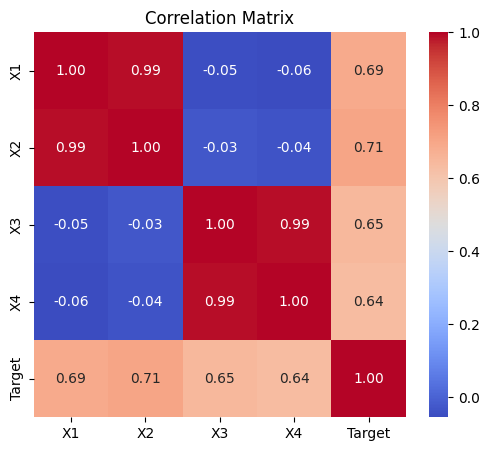

In [5]:
# We use the correlation matrix to detect high correlations (>0.8 or <-0.8).

plt.figure(figsize=(6,5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# If two independent variables have a correlation > 0.8 or < -0.8, they might cause multicollinearity.
# X1 and X2 & X3 and X4 are highly correlated.

In [6]:
# VIF tells us how much a variable is inflated due to correlation with other predictors

# Function to calculate VIF
def calculate_vif(df):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = df.columns
    vif_data["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    return vif_data

# Remove target variable for VIF calculation
X = df.drop(columns=['Target'])

# Calculate VIF
vif_df = calculate_vif(X)
print(vif_df)

# VIF > 10 → Severe multicollinearity (must be fixed)
# VIF between 5-10 → Moderate multicollinearity (consider fixing)
# VIF < 5 → No serious issue

  Feature         VIF
0      X1  452.263714
1      X2  452.835569
2      X3  502.438126
3      X4  494.677307


In [7]:
#  Fix Multicollinearity:

    # Option 1: Drop One of the Correlated Variables

df_fixed = df.drop(columns=['X2', 'X4'])  # Dropping one of the highly correlated variables


In [8]:
# Option 2: Use PCA (Principal Component Analysis)
# If you don’t want to drop variables, use PCA to transform correlated variables.

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Convert PCA results back to a DataFrame
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
print(df_pca.head())


          PC1         PC2
0  -85.367119 -141.723869
1  329.853889  194.481233
2  -86.994645   56.083726
3  122.842888 -124.447413
4  148.044903 -178.983082


## Example: Boston Housing Dataset

- ✔ Step 1: Check the correlation matrix to identify high correlations.
- ✔ Step 2: Use VIF to confirm multicollinearity.
- ✔ Step 3: Fix it by dropping features or using PCA.

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [10]:
# Load the dataset
boston = fetch_openml(name="boston", version=1, as_frame=True)
df = boston.frame

# Display first few rows
df.head()


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


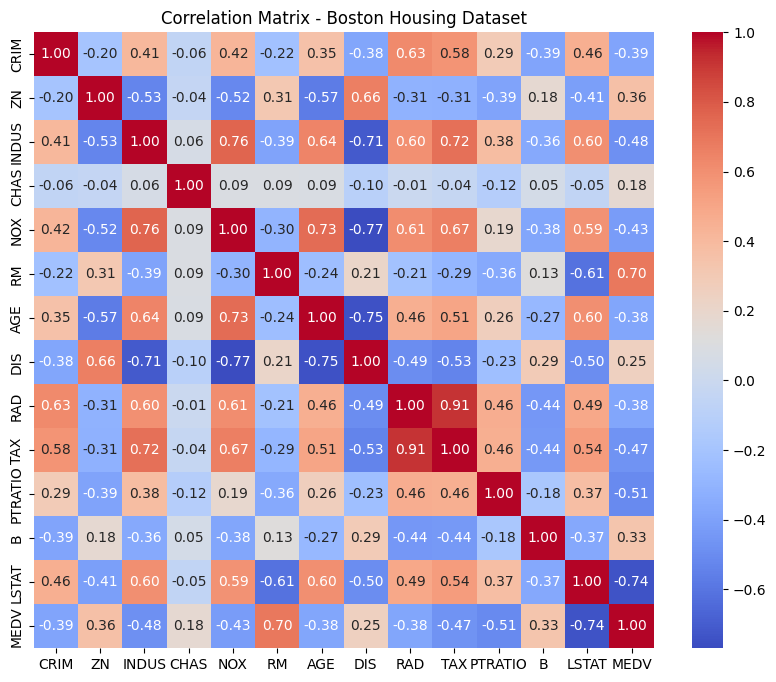

In [11]:
# To visualize multicollinearity, we plot a correlation heatmap:

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix - Boston Housing Dataset")
plt.show()


# Look for highly correlated features (>0.8 or <-0.8).
# Example: TAX (property tax) and RAD (highway accessibility) are highly correlated.

In [18]:
# We calculate VIF to confirm multicollinearity:

# Drop the target variable 'MEDV'
X = df.drop(columns=['target'])  

# Function to calculate VIF
def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data

# Compute VIF
vif_df = calculate_vif(X)
print(vif_df)

# VIF > 10 → Severe multicollinearity (e.g., TAX, RAD, NOX)
# VIF between 5-10 → Moderate multicollinearity (e.g., INDUS, LSTAT)

KeyError: "['target'] not found in axis"

In [13]:
# Fix Multicollinearity

# Option 1: Drop One of the Highly Correlated Features
# Since RAD and TAX are highly correlated, drop one:

df_fixed = df.drop(columns=['rad'])  # Dropping 'RAD'


KeyError: "['rad'] not found in axis"

In [14]:
# Option 2: Use PCA (Principal Component Analysis)
# If you want to keep all features, use PCA to reduce dimensionality:

from sklearn.decomposition import PCA

pca = PCA(n_components=10)  # Reduce to 10 components
X_pca = pca.fit_transform(X)

# Convert PCA results back to a DataFrame
df_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(10)])
print(df_pca.head())


ValueError: n_components=10 must be between 0 and min(n_samples, n_features)=4 with svd_solver='covariance_eigh'

# How to fic multicollieanrity?

## Remove One of the Correlated Variables
- If two variables are highly correlated (VIF > 10), drop one of them.
- If more than two variables are higly correlated, keep highly corelated feature.
    
    **When deciding which variables to remove:**
    
    - Keep variables with stronger theoretical justification
    - Retain variables that are easier to measure or obtain
    - Consider keeping variables that are more reliably measured

**📌 When to use?**

- When you don’t need both variables.
- When dropping a variable doesn’t reduce the model’s predictive power.



In [ ]:
df_fixed = df.drop(columns=['rad'])  # Dropping 'rad' because it's highly correlated with 'tax'


In [ ]:
# After identifying high VIF values or correlation coefficients
X = df.drop(['X2', 'X3'], axis=1)  # Drop the correlated features

# Verify VIF values after removal
remaining_features = X.columns
new_vif = calculate_vif(df, remaining_features)
print("VIF after removing correlated features:")
print(new_vif)

## Feature Engineering/Combination
Instead of removing variables, combine correlated features into a new variable:

In [ ]:
# Create a composite variable
df['X_combined'] = df['X1'] + df['X2'] + df['X3']
# Or use a weighted combination
df['X_weighted'] = 0.5*df['X1'] + 0.3*df['X2'] + 0.2*df['X3']

# Use the new composite feature instead of the original variables
X = df[['X_combined', 'X4']]

## Use Principal Component Analysis (PCA)
PCA transforms correlated variables into uncorrelated principal components.

**📌 When to use?**
- When all features contain important information, and you don’t want to drop any.

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize the data (important for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop(columns=['medv']))  # Exclude target variable

# Apply PCA
pca = PCA(n_components=10)  # Keep 10 principal components
X_pca = pca.fit_transform(X_scaled)

# Convert PCA results to a DataFrame
df_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(10)])
print(df_pca.head())


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=0.95)  # Keep components explaining 95% of variance
X_pca = pca.fit_transform(X_scaled)

# Use the transformed features in your model
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca, y, test_size=0.2)
model = LinearRegression().fit(X_train_pca, y_train)

## Use Ridge Regression (L2 Regularization)
Ridge regression reduces multicollinearity by shrinking coefficients.

**📌 When to use?**
- When you want to keep all variables but reduce the effect of multicollinearity.

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split

# Splitting data
X = df.drop(columns=['medv'])  # Features
y = df['medv']  # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Ridge Regression
ridge = Ridge(alpha=10)  # Higher alpha = stronger regularization
ridge.fit(X_train, y_train)

# Model score
print("Ridge R^2 Score:", ridge.score(X_test, y_test))


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Find optimal alpha parameter
alphas = np.logspace(-6, 6, 13)
ridge = Ridge()
ridge_cv = GridSearchCV(ridge, {'alpha': alphas}, cv=5)
ridge_cv.fit(X_train, y_train)

# Use the best model
best_ridge = Ridge(alpha=ridge_cv.best_params_['alpha'])
best_ridge.fit(X_train, y_train)
print("Ridge coefficients:", best_ridge.coef_)

## Use Lasso Regression (L1 Regularization)
Lasso regression automatically removes less important correlated features.

**📌 When to use?**
- When you want an automatic feature selection method.

In [ ]:
from sklearn.linear_model import Lasso

# Train Lasso Regression
lasso = Lasso(alpha=0.1)  # Alpha controls regularization strength
lasso.fit(X_train, y_train)

# Check which features were kept
selected_features = X.columns[lasso.coef_ != 0]
print("Selected Features:", selected_features)


In [ ]:
from sklearn.linear_model import Lasso

# Find optimal alpha parameter
lasso = Lasso()
lasso_cv = GridSearchCV(lasso, {'alpha': alphas}, cv=5)
lasso_cv.fit(X_train, y_train)

# Use the best model
best_lasso = Lasso(alpha=lasso_cv.best_params_['alpha'])
best_lasso.fit(X_train, y_train)
print("LASSO coefficients:", best_lasso.coef_)

## Elastic Net
Combines L1 and L2 penalties:

In [ ]:
from sklearn.linear_model import ElasticNet

# Find optimal parameters
param_grid = {
    'alpha': alphas,
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}
elastic = ElasticNet()
elastic_cv = GridSearchCV(elastic, param_grid, cv=5)
elastic_cv.fit(X_train, y_train)

# Use the best model
best_elastic = ElasticNet(
    alpha=elastic_cv.best_params_['alpha'], 
    l1_ratio=elastic_cv.best_params_['l1_ratio']
)
best_elastic.fit(X_train, y_train)

## Create Interaction Terms Instead of Individual Variables
Instead of using correlated variables separately, create interaction terms.

**📌 When to use?**
- When two correlated features together have meaning.



In [ ]:
df['interaction'] = df['tax'] * df['rad']
df_fixed = df.drop(columns=['tax', 'rad'])  # Replace highly correlated variables with interaction term


## Use Partial Least Squares (PLS) Regression
PLS is an alternative to PCA that retains interpretability while reducing dimensionality.

**📌 When to use?**
- When PCA loses interpretability, and you need a compromise.


In [ ]:
from sklearn.cross_decomposition import PLSRegression

pls = PLSRegression(n_components=5)  # Reduce to 5 components
pls.fit(X_train, y_train)

print("PLS R^2 Score:", pls.score(X_test, y_test))


In [ ]:
from sklearn.cross_decomposition import PLSRegression

# Try different numbers of components
pls = PLSRegression(n_components=2)
pls.fit(X_train, y_train)
print("PLS R² score:", pls.score(X_test, y_test))

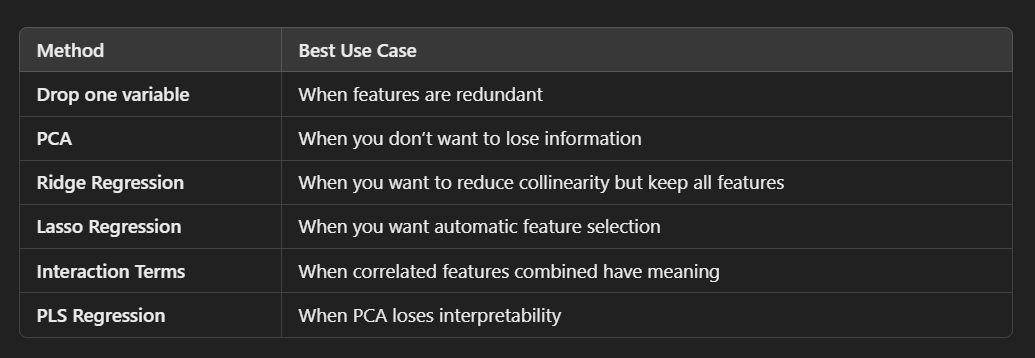

## Example:

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# Create a dataset with multicollinearity
np.random.seed(42)
n = 100

# Independent variable
X1 = np.random.normal(0, 1, n)
# Create correlated variables
X2 = X1 * 0.9 + np.random.normal(0, 0.1, n)  # Highly correlated with X1
X3 = X1 * 0.8 + np.random.normal(0, 0.2, n)  # Moderately correlated with X1
X4 = np.random.normal(0, 1, n)  # Independent variable

# Create target variable
y = 2*X1 + 0.5*X4 + np.random.normal(0, 1, n)

# Create DataFrame
df = pd.DataFrame({
    'X1': X1,
    'X2': X2,
    'X3': X3,
    'X4': X4,
    'y': y
})

df

,X1,X2,X3,X4,y
0,0.496714,0.305506,0.468929,-0.828995,-1.015497
1,-0.138264,-0.166502,0.001545,-0.560181,-1.155994
2,0.647689,0.548648,0.734761,0.747294,1.674268
3,1.523030,1.290499,1.429184,0.610370,3.398225
4,-0.234153,-0.226867,-0.462857,-0.020902,-0.928823
...,...,...,...,...,...
95,-1.463515,-1.278632,-1.309394,-0.469176,-2.622708
96,0.296120,0.178123,0.416816,-1.713135,-1.301573
97,0.261055,0.250322,0.270304,1.353872,1.008708
98,0.005113,0.010423,0.166663,-0.114540,-0.922661


### Correlation Matrix

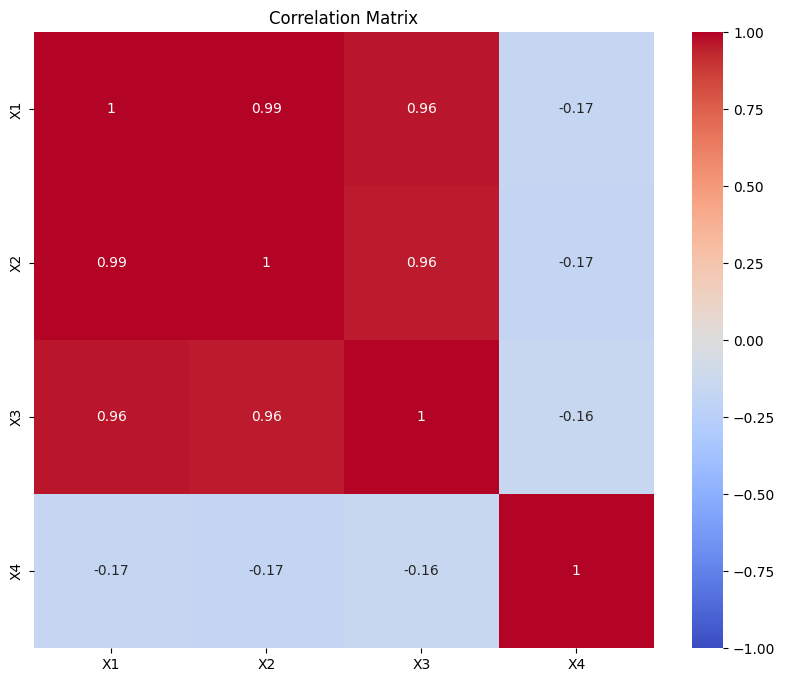

          X1        X2        X3        X4
X1  1.000000  0.993173  0.963660 -0.170227
X2  0.993173  1.000000  0.956741 -0.173873
X3  0.963660  0.956741  1.000000 -0.155271
X4 -0.170227 -0.173873 -0.155271  1.000000


In [20]:
# Calculate correlation matrix
correlation_matrix = df[['X1', 'X2', 'X3', 'X4']].corr()

# Visualize correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

print(correlation_matrix)

The output would show high correlations between X1, X2, and X3 (values close to 1), indicating multicollinearity.

### Variance Inflation Factor (VIF)
VIF is a powerful way to detect multicollinearity:

In [21]:
# Calculate VIF for each feature
def calculate_vif(df, features):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = features
    vif_data["VIF"] = [variance_inflation_factor(df[features].values, i)
                       for i in range(len(features))]
    return vif_data.sort_values("VIF", ascending=False)

features = ['X1', 'X2', 'X3', 'X4']
vif_results = calculate_vif(df, features)
print("VIF Values:")
print(vif_results)

VIF Values:
  Feature        VIF
0      X1  88.088809
1      X2  74.551287
2      X3  14.051569
3      X4   1.037599


VIF values greater than 5-10 typically indicate problematic multicollinearity.

### : Examining Regression Model Results
Let's see how multicollinearity affects our regression model:

In [22]:
# Add constant for statsmodels
X = sm.add_constant(df[['X1', 'X2', 'X3', 'X4']])
model = sm.OLS(df['y'], X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.746
Model:                            OLS   Adj. R-squared:                  0.736
Method:                 Least Squares   F-statistic:                     69.85
Date:                Mon, 31 Mar 2025   Prob (F-statistic):           1.86e-27
Time:                        09:48:36   Log-Likelihood:                -142.48
No. Observations:                 100   AIC:                             295.0
Df Residuals:                      95   BIC:                             308.0
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0888      0.105     -0.848      0.3

**Look for:**

- High standard errors
- Unexpected coefficient signs
- Insignificant variables that should be significant

### Method 1 - Removing Variables
The simplest approach is to remove highly correlated variables:

In [23]:
# Remove highly correlated variables
X_reduced = sm.add_constant(df[['X1', 'X4']])  # Keep only X1 and X4
model_reduced = sm.OLS(df['y'], X_reduced).fit()
print(model_reduced.summary())

# Check VIF after removal
reduced_features = ['X1', 'X4']
vif_reduced = calculate_vif(df, reduced_features)
print("VIF after variable removal:")
print(vif_reduced)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.735
Model:                            OLS   Adj. R-squared:                  0.729
Method:                 Least Squares   F-statistic:                     134.4
Date:                Mon, 31 Mar 2025   Prob (F-statistic):           1.09e-28
Time:                        09:50:04   Log-Likelihood:                -144.68
No. Observations:                 100   AIC:                             295.4
Df Residuals:                      97   BIC:                             303.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0938      0.106     -0.888      0.3

### Method 2 - Ridge Regression
Ridge regression adds a penalty term that shrinks coefficients, making it robust to multicollinearity:

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

# Prepare data
X = df[['X1', 'X2', 'X3', 'X4']]
y = df['y']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Ridge regression with cross-validation to find optimal alpha
ridge = Ridge()
alphas = np.logspace(-4, 2, 20)
param_grid = {'alpha': alphas}
ridge_cv = GridSearchCV(ridge, param_grid, cv=5)
ridge_cv.fit(X_train, y_train)

# Best model
best_alpha = ridge_cv.best_params_['alpha']
print(f"Best alpha: {best_alpha}")

# Fit Ridge with best alpha
best_ridge = Ridge(alpha=best_alpha)
best_ridge.fit(X_train, y_train)
print("Ridge coefficients:", best_ridge.coef_)

Best alpha: 1.2742749857031321
Ridge coefficients: [ 0.78642631  1.12081515 -0.21086367  0.61807303]


### Method 3 - LASSO Regression
LASSO can also handle multicollinearity and performs feature selection by reducing some coefficients to zero:

In [25]:
# LASSO regression with cross-validation
lasso = Lasso()
lasso_cv = GridSearchCV(lasso, param_grid, cv=5)
lasso_cv.fit(X_train, y_train)

# Best model
best_alpha_lasso = lasso_cv.best_params_['alpha']
print(f"Best alpha for LASSO: {best_alpha_lasso}")

# Fit LASSO with best alpha
best_lasso = Lasso(alpha=best_alpha_lasso)
best_lasso.fit(X_train, y_train)
print("LASSO coefficients:", best_lasso.coef_)

Best alpha for LASSO: 0.03359818286283781
LASSO coefficients: [ 0.22206171  1.46201577 -0.          0.59363095]


### Method 4 - Principal Component Analysis (PCA)
PCA transforms correlated variables into uncorrelated components:

In [26]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# Create PCA pipeline
pca = PCA(n_components=2)  # Reduce to 2 principal components
X_pca = pca.fit_transform(X_scaled)

# Variance explained by each component
print("Variance explained by components:", pca.explained_variance_ratio_)

# Create a regression model with PCA
pca_pipe = Pipeline([
    ('pca', PCA(n_components=2)),
    ('regression', LinearRegression())
])

pca_pipe.fit(X_train, y_train)
print("Model score with PCA:", pca_pipe.score(X_test, y_test))

Variance explained by components: [0.74609461 0.23956487]
Model score with PCA: 0.7584236025542592
